# Mejora de modelos y modelo multimodal

Este notebook está dedicado a:
1. Guardar el modelo clínico final (Random Forest) ya entrenado.
2. Mejorar el modelo de imágenes (CNN con EfficientNetB0) manejando el desbalance de clases.
3. Construir un modelo multimodal sencillo que combine la señal clínica y la señal de imágenes.

## 1. Guardar modelo clínico (Random Forest)

En esta sección simplemente se vuelve a entrenar o recargar el modelo Random Forest clínico final (código copiado desde el notebook de experimentos) y se guarda en disco para poder reutilizarlo en la etapa de despliegue y en el modelo multimodal.

In [3]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import EfficientNetB0

from collections import Counter
from pathlib import Path
import joblib

ruta_proyecto = Path("..").resolve()
ruta_modelos = ruta_proyecto / "Modelos Guardados"
ruta_modelos.mkdir(exist_ok=True)

In [7]:
print('Versión de TensorFlow:', tf.__version__)

ruta_datasets = ruta_proyecto / "datasets"
print('Ruta base de datasets:', os.path.abspath(ruta_base_datasets))

Versión de TensorFlow: 2.17.0
Ruta base de datasets: c:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV\datasets


In [8]:
ruta_train_clinico = ruta_datasets / "clinical_features_train.csv"
ruta_valid_clinico = ruta_datasets / "clinical_features_valid.csv"
ruta_test_clinico  = ruta_datasets / "clinical_features_test.csv"

df_train = pd.read_csv(ruta_train_clinico)
df_valid = pd.read_csv(ruta_valid_clinico)
df_test  = pd.read_csv(ruta_test_clinico)

print('Tamaño train:', df_train.shape)
print('Tamaño valid:', df_valid.shape)
print('Tamaño test :', df_test.shape)

df_train.head()

Tamaño train: (3509, 73)
Tamaño valid: (752, 73)
Tamaño test : (752, 73)


,Age,Weight_kg,target_derm,age_squared,weight_zscore_by_breed,age_weight_interaction,breed_is_other,is_vaccinated,has_parasite_history,has_chronic_illness,...,breed_grouped_german shepherd,breed_grouped_golden retriever,breed_grouped_labrador retriever,breed_grouped_mixed breed,breed_grouped_poodle,breed_grouped_rottweiler,breed_grouped_yorkshire terrier,age_bucket_puppy,age_bucket_adult,age_bucket_senior
0,5.8,22.9,1,33.64,-1.787272,132.82,0,0,0,0,...,False,False,False,False,False,True,False,False,True,False
1,9.4,3.8,1,88.36,-1.174947,35.72,0,1,0,0,...,False,False,False,False,True,False,False,False,False,True
2,1.8,4.4,1,3.24,-0.930756,7.92,0,0,0,0,...,False,False,False,False,False,False,True,False,True,False
3,8.2,4.4,1,67.24,-0.930756,36.08,0,0,0,0,...,False,False,False,False,False,False,True,False,False,True
4,14.6,8.0,0,213.16,0.919236,116.80,0,0,0,0,...,False,False,False,False,False,False,True,False,False,True


In [9]:
columna_objetivo = 'target_derm'

for nombre, df in [('train', df_train), ('valid', df_valid), ('test', df_test)]:
    distribucion = df[columna_objetivo].value_counts(normalize=True).sort_index()
    print(f"\nDistribución objetivo ({nombre}):")
    print(distribucion)
    print('Proporciones (%)')
    print((distribucion * 100).round(2))


Distribución objetivo (train):
target_derm
0    0.796523
1    0.203477
Name: proportion, dtype: float64
Proporciones (%)
target_derm
0    79.65
1    20.35
Name: proportion, dtype: float64

Distribución objetivo (valid):
target_derm
0    0.796543
1    0.203457
Name: proportion, dtype: float64
Proporciones (%)
target_derm
0    79.65
1    20.35
Name: proportion, dtype: float64

Distribución objetivo (test):
target_derm
0    0.796543
1    0.203457
Name: proportion, dtype: float64
Proporciones (%)
target_derm
0    79.65
1    20.35
Name: proportion, dtype: float64


In [10]:
columnas_features = [c for c in df_train.columns if c != columna_objetivo]

X_train = df_train[columnas_features].values
y_train = df_train[columna_objetivo].values

X_valid = df_valid[columnas_features].values
y_valid = df_valid[columna_objetivo].values

X_test = df_test[columnas_features].values
y_test = df_test[columna_objetivo].values

len(columnas_features), columnas_features[:10]

(72,
 ['Age',
  'Weight_kg',
  'age_squared',
  'weight_zscore_by_breed',
  'age_weight_interaction',
  'breed_is_other',
  'is_vaccinated',
  'has_parasite_history',
  'has_chronic_illness',
  'has_allergies'])

In [11]:
def evaluar_en_split(modelo, X, y, nombre_split='valid'):
    y_pred = modelo.predict(X)
    acc = accuracy_score(y, y_pred)
    bacc = balanced_accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average='macro')
    print(f"\nResultados en {nombre_split}:")
    print(f"Accuracy:           {acc:.4f}")
    print(f"Balanced accuracy:  {bacc:.4f}")
    print(f"F1 macro:           {f1:.4f}")
    print("\nReporte de clasificación:")
    print(classification_report(y, y_pred, digits=4))
    print("\nMatriz de confusión:")
    print(confusion_matrix(y, y_pred))
    return {'accuracy': acc, 'balanced_accuracy': bacc, 'f1_macro': f1}

def graficar_importancias(features, importancias, top_n=15, titulo='Importancia de variables'):
    idx = np.argsort(importancias)[-top_n:]
    plt.figure(figsize=(8, 6))
    plt.barh(range(len(idx)), importancias[idx])
    plt.yticks(range(len(idx)), [features[i] for i in idx])
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

In [12]:
pipe_logreg = Pipeline([
    ('escalador', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pipe_logreg.fit(X_train, y_train)
resultados_logreg_valid = evaluar_en_split(pipe_logreg, X_valid, y_valid, nombre_split='valid (LogReg)')


Resultados en valid (LogReg):
Accuracy:           0.9840
Balanced accuracy:  0.9681
F1 macro:           0.9750

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9851    0.9950    0.9900       599
           1     0.9796    0.9412    0.9600       153

    accuracy                         0.9840       752
   macro avg     0.9824    0.9681    0.9750       752
weighted avg     0.9840    0.9840    0.9839       752


Matriz de confusión:
[[596   3]
 [  9 144]]


In [13]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
resultados_rf_valid = evaluar_en_split(rf, X_valid, y_valid, nombre_split='valid (Random Forest)')


Resultados en valid (Random Forest):
Accuracy:           0.9867
Balanced accuracy:  0.9673
F1 macro:           0.9790

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9836    1.0000    0.9917       599
           1     1.0000    0.9346    0.9662       153

    accuracy                         0.9867       752
   macro avg     0.9918    0.9673    0.9790       752
weighted avg     0.9869    0.9867    0.9865       752


Matriz de confusión:
[[599   0]
 [ 10 143]]


In [14]:
resultados_tabular = pd.DataFrame([
    {'modelo': 'LogisticRegression', **resultados_logreg_valid},
    {'modelo': 'RandomForest', **resultados_rf_valid}
])

resultados_tabular

,modelo,accuracy,balanced_accuracy,f1_macro
0,LogisticRegression,0.984043,0.968084,0.975017
1,RandomForest,0.986702,0.967320,0.978969


In [15]:
mejor_fila = resultados_tabular.sort_values('f1_macro', ascending=False).iloc[0]
modelo_ganador_nombre = mejor_fila['modelo']
print('Mejor modelo según F1 macro en validación:', modelo_ganador_nombre)

if modelo_ganador_nombre == 'LogisticRegression':
    modelo_ganador = pipe_logreg
else:
    modelo_ganador = rf

Mejor modelo según F1 macro en validación: RandomForest


In [16]:
X_train_full = np.vstack([X_train, X_valid])
y_train_full = np.concatenate([y_train, y_valid])

if modelo_ganador_nombre == 'LogisticRegression':
    modelo_final = Pipeline([
        ('escalador', StandardScaler()),
        ('modelo', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])
else:
    modelo_final = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )

modelo_final.fit(X_train_full, y_train_full)
resultados_test_tabular = evaluar_en_split(modelo_final, X_test, y_test, nombre_split='test (modelo final tabular)')
resultados_test_tabular


Resultados en test (modelo final tabular):
Accuracy:           0.9827
Balanced accuracy:  0.9575
F1 macro:           0.9724

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9788    1.0000    0.9893       599
           1     1.0000    0.9150    0.9556       153

    accuracy                         0.9827       752
   macro avg     0.9894    0.9575    0.9724       752
weighted avg     0.9831    0.9827    0.9824       752


Matriz de confusión:
[[599   0]
 [ 13 140]]


{'accuracy': 0.9827127659574468,
 'balanced_accuracy': 0.957516339869281,
 'f1_macro': 0.9724482347536659}

In [17]:
# Renombrar el modelo final como modelo_rf_clinico para dejarlo claro
modelo_rf_clinico = modelo_final

# Guardar el modelo Random Forest clínico entrenado
archivo_modelo_rf = ruta_modelos / "modelo_rf_clinico.joblib"
joblib.dump(modelo_rf_clinico, archivo_modelo_rf)

print(f"Modelo Random Forest clínico guardado en: {archivo_modelo_rf}")


Modelo Random Forest clínico guardado en: C:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV\Modelos Guardados\modelo_rf_clinico.joblib


## 2. Mejora del modelo de imágenes (CNN con EfficientNetB0)

En esta sección se redefine y entrena una CNN basada en EfficientNetB0 para el dataset de enfermedades de piel en perros.  
Se aplican:
- Aumento de datos más agresivo para mejorar la generalización.
- Cálculo de `class_weight` para manejar el desbalance entre clases.
- Entrenamiento en dos fases: cabeza densa y luego *fine-tuning* de las últimas capas del backbone.
- Evaluación en el conjunto de prueba con métricas como accuracy y F1 macro.

Al final se guarda el modelo de imágenes ya entrenado para reutilizarlo en el modelo multimodal.

In [30]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
import json

# Aseguramos que la carpeta de modelos exista (se definió en la sección 1,
# pero la volvemos a crear por seguridad en caso de ejecutar celdas sueltas).
ruta_proyecto = Path("..").resolve()
ruta_modelos = ruta_proyecto / "Modelos Guardados"
ruta_modelos.mkdir(exist_ok=True)

In [31]:
# Rutas del dataset de imágenes (ajustar si la estructura es diferente)
ruta_datasets = ruta_proyecto / "datasets"

ruta_entrenamiento = ruta_datasets / "train"
ruta_validacion    = ruta_datasets / "valid"
ruta_prueba        = ruta_datasets / "test"

tam_imagen = (224, 224)
tam_lote = 32
semilla = 42

print("Ruta entrenamiento:", ruta_entrenamiento)
print("Ruta validación  :", ruta_validacion)
print("Ruta prueba      :", ruta_prueba)

Ruta entrenamiento: C:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV\datasets\train
Ruta validación  : C:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV\datasets\valid
Ruta prueba      : C:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV\datasets\test


In [32]:
from tensorflow.keras.applications.efficientnet import preprocess_input

generador_entrenamiento = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

generador_validacion = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

generador_prueba = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

datos_entrenamiento = generador_entrenamiento.flow_from_directory(
    ruta_entrenamiento,
    target_size=tam_imagen,
    batch_size=tam_lote,
    class_mode="categorical",
    shuffle=True,
    seed=semilla
)

datos_validacion = generador_validacion.flow_from_directory(
    ruta_validacion,
    target_size=tam_imagen,
    batch_size=tam_lote,
    class_mode="categorical",
    shuffle=False
)

datos_prueba = generador_prueba.flow_from_directory(
    ruta_prueba,
    target_size=tam_imagen,
    batch_size=tam_lote,
    class_mode="categorical",
    shuffle=False
)


Found 3022 images belonging to 6 classes.
Found 860 images belonging to 6 classes.
Found 433 images belonging to 6 classes.


In [33]:
# Cálculo de pesos de clase para manejar desbalance
clases_entrenamiento = datos_entrenamiento.classes
clases_unicas = np.unique(clases_entrenamiento)

pesos = compute_class_weight(
    class_weight="balanced",
    classes=clases_unicas,
    y=clases_entrenamiento
)
pesos_clase = dict(zip(clases_unicas, pesos))

print("Pesos de clase:")
for idx, peso in pesos_clase.items():
    nombre_clase = [n for n, i in datos_entrenamiento.class_indices.items() if i == idx][0]
    print(f"  {idx} ({nombre_clase}): {peso:.3f}")

# Guardar mapeo de clases para usar luego en el modelo multimodal/GUI
clases_a_indices = datos_entrenamiento.class_indices
indices_a_clases = {idx: nombre for nombre, idx in clases_a_indices.items()}

with open(ruta_modelos / "clases_cnn_imagenes.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "clases_a_indices": clases_a_indices,
            "indices_a_clases": indices_a_clases
        },
        f,
        ensure_ascii=False,
        indent=2
    )

print("Diccionario de clases guardado en:", ruta_modelos / "clases_cnn_imagenes.json")

Pesos de clase:
  0 (Dermatitis): 0.922
  1 (Fungal_infections): 1.343
  2 (Healthy): 1.024
  3 (Hypersensitivity): 2.190
  4 (demodicosis): 0.857
  5 (ringworm): 0.637
Diccionario de clases guardado en: C:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV\Modelos Guardados\clases_cnn_imagenes.json


In [34]:
# Definición del modelo EfficientNetB0 + cabeza densa

base_modelo = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(tam_imagen[0], tam_imagen[1], 3)
)

# Fase 1: congelamos el backbone
base_modelo.trainable = False

entrada = base_modelo.input
x = GlobalAveragePooling2D()(base_modelo.output)
x = Dropout(0.3)(x)
salida = Dense(datos_entrenamiento.num_classes, activation="softmax")(x)

modelo_cnn = Model(inputs=entrada, outputs=salida)

modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_cnn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [35]:
# Callbacks para early stopping, reducción de LR y guardado de mejores pesos
ruta_pesos_temporales = ruta_modelos / "cnn_piel_perros_mejorada_tmp.weights.h5"

callbacks_cnn = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        filepath=str(ruta_pesos_temporales),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True
    )
]

In [36]:
# Fase 1: entrenar solo la cabeza densa
epocas_fase1 = 15

historia_fase1 = modelo_cnn.fit(
    datos_entrenamiento,
    validation_data=datos_validacion,
    epochs=epocas_fase1,
    callbacks=callbacks_cnn
)


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 54s 513ms/step - accuracy: 0.4221 - loss: 1.4476 - val_accuracy: 0.6849 - val_loss: 0.8773 - learning_rate: 0.0010
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 48s 504ms/step - accuracy: 0.7049 - loss: 0.8238 - val_accuracy: 0.7547 - val_loss: 0.7035 - learning_rate: 0.0010
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 47s 495ms/step - accuracy: 0.7559 - loss: 0.7068 - val_accuracy: 0.7791 - val_loss: 0.5980 - learning_rate: 0.0010
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 46s 487ms/step - accuracy: 0.8018 - loss: 0.6076 - val_accuracy: 0.8105 - val_loss: 0.5490 - learning_rate: 0.0010
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 46s 487ms/step - accuracy: 0.8103 - loss: 0.5673 - val_accuracy: 0.8198 - val_loss: 0.5205 - learning_rate: 0.0010
Epoch 6/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 47s 491ms/step - accuracy: 0.8271 - loss: 0.5425 - val_accuracy: 0.8442 - val_loss: 0.4720 - learning_rate: 0.0010
Epoch 7/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 47s 495ms/step - accuracy: 0.8332 - loss: 0.

In [37]:
# Fase 2: fine-tuning de las últimas capas del backbone

# Descongelamos las últimas N capas de EfficientNetB0
n_capas_descongelar = 40  # se puede ajustar
for capa in base_modelo.layers[-n_capas_descongelar:]:
    capa.trainable = True

modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

epocas_fase2 = 15

historia_fase2 = modelo_cnn.fit(
    datos_entrenamiento,
    validation_data=datos_validacion,
    epochs=epocas_fase2,
    callbacks=callbacks_cnn
)

Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.7194 - loss: 0.7571 - val_accuracy: 0.8605 - val_loss: 0.4213 - learning_rate: 1.0000e-05
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 136s 791ms/step - accuracy: 0.7933 - loss: 0.6116 - val_accuracy: 0.8500 - val_loss: 0.4540 - learning_rate: 1.0000e-05
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 56s 589ms/step - accuracy: 0.7988 - loss: 0.5801 - val_accuracy: 0.8488 - val_loss: 0.4614 - learning_rate: 1.0000e-05
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 58s 610ms/step - accuracy: 0.8211 - loss: 0.5223 - val_accuracy: 0.8500 - val_loss: 0.4616 - learning_rate: 5.0000e-06
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 56s 590ms/step - accuracy: 0.8351 - loss: 0.5231 - val_accuracy: 0.8535 - val_loss: 0.4582 - learning_rate: 5.0000e-06


In [38]:
# Cargar los mejores pesos encontrados durante el entrenamiento
modelo_cnn.load_weights(ruta_pesos_temporales)

# Evaluación en el conjunto de prueba
loss_test, acc_test = modelo_cnn.evaluate(datos_prueba)
print(f"Loss test: {loss_test:.4f}")
print(f"Accuracy test: {acc_test:.4f}")

# Predicciones para métricas adicionales
probas_test = modelo_cnn.predict(datos_prueba)
pred_indices = np.argmax(probas_test, axis=1)
y_verdadero = datos_prueba.classes

nombres_clases = list(datos_prueba.class_indices.keys())

print("\nReporte de clasificación (test):")
print(classification_report(y_verdadero, pred_indices, target_names=nombres_clases))

f1_macro = f1_score(y_verdadero, pred_indices, average="macro")
print(f"F1 macro (test): {f1_macro:.4f}")

matriz_confusion = confusion_matrix(y_verdadero, pred_indices)
print("\nMatriz de confusión:")
print(matriz_confusion)

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'adam', because it has 78 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 295ms/step - accuracy: 0.7909 - loss: 0.5415
Loss test: 0.4461
Accuracy test: 0.8406
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 371ms/step

Reporte de clasificación (test):
                   precision    recall  f1-score   support

       Dermatitis       0.74      0.83      0.79        66
Fungal_infections       0.81      0.48      0.60        54
          Healthy       0.90      0.93      0.91        69
 Hypersensitivity       0.77      0.59      0.67        29
      demodicosis       0.90      0.95      0.92       100
         ringworm       0.84      0.93      0.88       115

         accuracy                           0.84       433
        macro avg       0.83      0.78      0.80       433
     weighted avg       0.84      0.84      0.83       433

F1 macro (test): 0.7957

Matriz de confusión:
[[ 55   1   0   1   2   7]
 [  9  26   5   3   5   6]
 [  0   3  64   1   1   0]
 [  3   2   2  17   1   4]
 [  1   0   0   0  95   4]
 [  6   0   0   0   2 107]]


In [39]:
# Guardar modelo CNN mejorado completo
archivo_modelo_cnn = ruta_modelos / "modelo_cnn_piel_perros.keras"
modelo_cnn.save(archivo_modelo_cnn)

print(f"Modelo CNN de piel de perros guardado en: {archivo_modelo_cnn}")

Modelo CNN de piel de perros guardado en: C:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV\Modelos Guardados\modelo_cnn_piel_perros.keras


## 3. Modelo multimodal (Random Forest clínico + CNN de imágenes)

En esta sección se construye un modelo multimodal sencillo que combina:

- La probabilidad de caso dermatológico obtenida del Random Forest clínico.
- Las probabilidades por clase producidas por la CNN de imágenes.

Con estas salidas se entrena un meta-modelo (Regresión Logística) que actúa como clasificador final.  
Este bloque asume que existe un dataset tabular con la unión de información clínica e imágenes para cada paciente/perro.

In [40]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from joblib import load
from tensorflow.keras.preprocessing import image
import tensorflow as tf
from pathlib import Path

ruta_proyecto = Path("..").resolve()
ruta_modelos = ruta_proyecto / "Modelos Guardados"
ruta_modelos.mkdir(exist_ok=True)

In [41]:
# Cargar modelos base
modelo_rf_clinico = load(ruta_modelos / "modelo_rf_clinico.joblib")
modelo_cnn_imagenes = tf.keras.models.load_model(ruta_modelos / "modelo_cnn_piel_perros.keras")

print("Modelos base cargados correctamente.")

Modelos base cargados correctamente.


In [42]:
# -------------------------------------------------------------
# Cargar datasets multimodales sintéticos (train/valid/test)
# -------------------------------------------------------------

ruta_mm_train = ruta_datasets / "multimodal_train.csv"
ruta_mm_valid = ruta_datasets / "multimodal_valid.csv"
ruta_mm_test  = ruta_datasets / "multimodal_test.csv"

df_mm_train = pd.read_csv(ruta_mm_train)
df_mm_valid = pd.read_csv(ruta_mm_valid)
df_mm_test  = pd.read_csv(ruta_mm_test)

# Para entrenar el meta-modelo usamos train + valid
df_multimodal = pd.concat([df_mm_train, df_mm_valid], ignore_index=True)

columnas_excluir = ["ruta_imagen", "target_derm"]
columnas_clinicas = [c for c in df_multimodal.columns if c not in columnas_excluir]

X_clinico = df_multimodal[columnas_clinicas]
rutas_imagen = df_multimodal["ruta_imagen"]
y_multimodal = df_multimodal["target_derm"]

print("Tamaño multimodal_train:", df_mm_train.shape)
print("Tamaño multimodal_valid:", df_mm_valid.shape)
print("Tamaño multimodal_test :", df_mm_test.shape)
print("Muestras usadas para meta-modelo (train+valid):", len(df_multimodal))
print("Número de variables clínicas:", len(columnas_clinicas))


Tamaño multimodal_train: (3509, 74)
Tamaño multimodal_valid: (752, 74)
Tamaño multimodal_test : (752, 74)
Muestras usadas para meta-modelo (train+valid): 4261
Número de variables clínicas: 72


In [43]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

def cargar_imagen_procesada(ruta_imagen, tam_imagen=(224, 224)):
    """
    Carga una imagen a partir de una ruta relativa (respecto a 'datasets')
    o absoluta y aplica el mismo preprocesamiento que en el entrenamiento
    de la CNN (preprocess_input de EfficientNetB0).
    """
    ruta_imagen = Path(ruta_imagen)
    if ruta_imagen.is_absolute():
        ruta_real = ruta_imagen
    else:
        ruta_real = ruta_datasets / ruta_imagen

    img = image.load_img(ruta_real, target_size=tam_imagen)
    arr = image.img_to_array(img)
    arr = preprocess_input(arr)
    return arr

# Probabilidades clínicas (salida del Random Forest)
probas_clinicas = modelo_rf_clinico.predict_proba(X_clinico.values)[:, 1]

# Probabilidades de la CNN (por clase) para cada imagen
X_imagenes = np.stack([cargar_imagen_procesada(r) for r in rutas_imagen])
probas_imagenes = modelo_cnn_imagenes.predict(X_imagenes, batch_size=32)

print("Forma de probas_clinicas:", probas_clinicas.shape)
print("Forma de probas_imagenes:", probas_imagenes.shape)


134/134 ━━━━━━━━━━━━━━━━━━━━ 38s 274ms/step
Forma de probas_clinicas: (4261,)
Forma de probas_imagenes: (4261, 6)


In [44]:
# Construir matriz de características para el meta-modelo:
# columna 0: probabilidad clínica
# columnas restantes: probabilidades por clase de la CNN

X_meta = np.column_stack([probas_clinicas, probas_imagenes])
y_meta = y_multimodal.values

X_meta_train, X_meta_valid, y_meta_train, y_meta_valid = train_test_split(
    X_meta,
    y_meta,
    test_size=0.2,
    random_state=42,
    stratify=y_meta
)

meta_modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

meta_modelo.fit(X_meta_train, y_meta_train)

y_valid_pred = meta_modelo.predict(X_meta_valid)
y_valid_proba = meta_modelo.predict_proba(X_meta_valid)[:, 1]

print("Reporte de clasificación (meta-modelo, valid):")
print(classification_report(y_meta_valid, y_valid_pred))

print("Accuracy (valid):", accuracy_score(y_meta_valid, y_valid_pred))
print("F1 macro (valid):", f1_score(y_meta_valid, y_valid_pred, average="macro"))

Reporte de clasificación (meta-modelo, valid):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       679
           1       1.00      1.00      1.00       174

    accuracy                           1.00       853
   macro avg       1.00      1.00      1.00       853
weighted avg       1.00      1.00      1.00       853

Accuracy (valid): 1.0
F1 macro (valid): 1.0


In [45]:
# Guardar meta-modelo multimodal
archivo_modelo_multimodal = ruta_modelos / "modelo_multimodal.joblib"

joblib.dump(meta_modelo, archivo_modelo_multimodal)

print(f"Modelo multimodal guardado en: {archivo_modelo_multimodal}")

Modelo multimodal guardado en: C:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV\Modelos Guardados\modelo_multimodal.joblib


In [ ]:
def predecir_riesgo_dermatologico_multimodal(
    fila_clinica,
    ruta_imagen,
    modelo_rf,
    modelo_cnn,
    modelo_meta,
    tam_imagen=(224, 224)
):
    """Devuelve la probabilidad final de caso dermatológico combinando
    información clínica e imagen.

    - fila_clinica: Series o array con las mismas columnas usadas en el RF.
    - ruta_imagen: ruta a la imagen del paciente/perro.
    """
    # Probabilidad clínica
    if hasattr(fila_clinica, "values"):
        X_clin = fila_clinica.values.reshape(1, -1)
    else:
        X_clin = np.array(fila_clinica, dtype=float).reshape(1, -1)
    proba_clin = modelo_rf.predict_proba(X_clin)[:, 1]  # shape (1,)

    # Probabilidades de la CNN
    arr_img = cargar_imagen_procesada(ruta_imagen, tam_imagen=tam_imagen)
    proba_img = modelo_cnn.predict(arr_img[np.newaxis, ...])[0]  # shape (n_clases,)

    # Vector de entrada al meta-modelo
    X_meta_nueva = np.column_stack([proba_clin, proba_img.reshape(1, -1)])

    # Probabilidad final
    proba_final = modelo_meta.predict_proba(X_meta_nueva)[0, 1]
    return proba_final


================ Ejemplo 1 ================
Etiqueta real target_derm: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Ruta imagen: test\Healthy\images-15_jpg.rf.3f747c364fec0a6b77f4c3993e2c3e23.jpg
RF clínico -> P(derm):                0.027
CNN imágenes -> clase predicha: Healthy (p=0.845)
CNN imágenes -> P(healthy):          0.845
CNN imágenes -> P(enfermo≈1-healthy): 0.155
Multimodal (meta-modelo) -> P(derm):  0.003


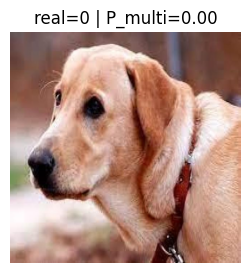


================ Ejemplo 2 ================
Etiqueta real target_derm: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Ruta imagen: test\Healthy\Image_10_jpeg_jpg.rf.cc9236214504f142db7dfd07bfb9bb6b.jpg
RF clínico -> P(derm):                0.013
CNN imágenes -> clase predicha: Healthy (p=0.909)
CNN imágenes -> P(healthy):          0.909
CNN imágenes -> P(enfermo≈1-healthy): 0.091
Multimodal (meta-modelo) -> P(derm):  0.002


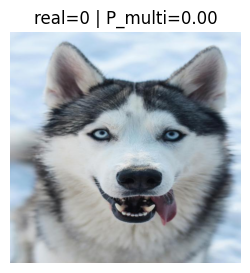


================ Ejemplo 3 ================
Etiqueta real target_derm: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Ruta imagen: test\demodicosis\IMG_5164_jpeg_jpg.rf.ab63d49ffaeddcc29bc37bb4dd8d666a.jpg
RF clínico -> P(derm):                0.993
CNN imágenes -> clase predicha: demodicosis (p=0.997)
CNN imágenes -> P(healthy):          0.000
CNN imágenes -> P(enfermo≈1-healthy): 1.000
Multimodal (meta-modelo) -> P(derm):  0.998


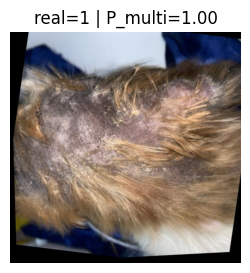


================ Ejemplo 4 ================
Etiqueta real target_derm: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Ruta imagen: test\Healthy\Image_9_jpg.rf.99788b2c41ce48033edb8038f6952bef.jpg
RF clínico -> P(derm):                0.033
CNN imágenes -> clase predicha: Healthy (p=0.938)
CNN imágenes -> P(healthy):          0.938
CNN imágenes -> P(enfermo≈1-healthy): 0.062
Multimodal (meta-modelo) -> P(derm):  0.002


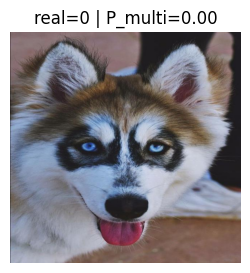


================ Ejemplo 5 ================
Etiqueta real target_derm: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Ruta imagen: test\Healthy\dogs_021_jpg.rf.f1b30730b70ca2eefeba245fe0e590ba.jpg
RF clínico -> P(derm):                0.067
CNN imágenes -> clase predicha: Healthy (p=0.867)
CNN imágenes -> P(healthy):          0.867
CNN imágenes -> P(enfermo≈1-healthy): 0.133
Multimodal (meta-modelo) -> P(derm):  0.004


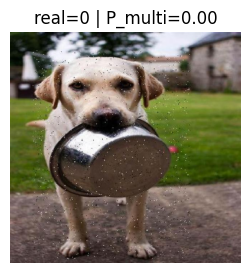

In [47]:
import json
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Cargar diccionario de clases de la CNN
ruta_clases_cnn = ruta_modelos / "clases_cnn_imagenes.json"
with open(ruta_clases_cnn, "r", encoding="utf-8") as f:
    info_clases = json.load(f)

# Asegurarnos de que las claves son int
indices_a_clases = {int(k): v for k, v in info_clases["indices_a_clases"].items()}

# Localizar el índice de la clase Healthy
idx_healthy = None
for idx, nombre in indices_a_clases.items():
    if nombre.lower() == "healthy":
        idx_healthy = idx
        break

def probar_modelo_multimodal(n_muestras=5, tam_imagen=(224, 224)):
    """
    Imprime y visualiza algunas predicciones del modelo multimodal
    usando el split de prueba multimodal (df_mm_test).
    """
    muestras = df_mm_test.sample(n_muestras, random_state=42).reset_index(drop=True)

    for i, fila in muestras.iterrows():
        print(f"\n================ Ejemplo {i+1} ================")
        print("Etiqueta real target_derm:", fila["target_derm"])

        ruta_rel = fila["ruta_imagen"]
        ruta_abs = ruta_datasets / ruta_rel

        # --------- Probabilidad clínica (RF) ---------
        fila_clinica = fila[columnas_clinicas]
        X_clin = fila_clinica.values.reshape(1, -1)
        proba_rf = modelo_rf_clinico.predict_proba(X_clin)[0, 1]

        # --------- Probabilidades de la CNN ---------
        arr_img = cargar_imagen_procesada(ruta_rel, tam_imagen=tam_imagen)
        probas_cnn = modelo_cnn_imagenes.predict(arr_img[np.newaxis, ...])[0]
        idx_max = np.argmax(probas_cnn)
        clase_pred = indices_a_clases[idx_max]
        proba_max = probas_cnn[idx_max]

        if idx_healthy is not None:
            proba_healthy = probas_cnn[idx_healthy]
            proba_enfermo = 1.0 - proba_healthy
        else:
            proba_healthy = None
            proba_enfermo = None

        # --------- Probabilidad multimodal ---------
        proba_multi = predecir_riesgo_dermatologico_multimodal(
            fila_clinica,
            ruta_rel,
            modelo_rf_clinico,
            modelo_cnn_imagenes,
            meta_modelo,
            tam_imagen=tam_imagen
        )

        print(f"Ruta imagen: {ruta_rel}")
        print(f"RF clínico -> P(derm):                {proba_rf:.3f}")
        print(f"CNN imágenes -> clase predicha: {clase_pred} (p={proba_max:.3f})")
        if proba_healthy is not None:
            print(f"CNN imágenes -> P(healthy):          {proba_healthy:.3f}")
            print(f"CNN imágenes -> P(enfermo≈1-healthy): {proba_enfermo:.3f}")
        print(f"Multimodal (meta-modelo) -> P(derm):  {proba_multi:.3f}")

        # --------- Mostrar imagen ---------
        plt.figure(figsize=(3, 3))
        img_mostrar = image.load_img(ruta_abs)
        plt.imshow(img_mostrar)
        plt.axis("off")
        plt.title(f"real={fila['target_derm']} | P_multi={proba_multi:.2f}")
        plt.show()


# Llamada de prueba
probar_modelo_multimodal(n_muestras=5)
